In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Dataset Information")
print("=" * 40)

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Description:")
print(df.describe())

Dataset Information
Dataset Shape: (20640, 9)

Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Dataset Description:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   172

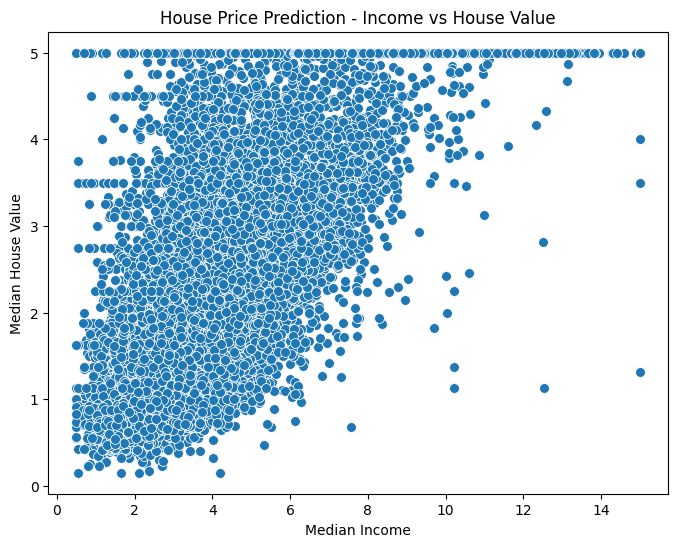

In [4]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="MedInc",
    y="MedHouseVal",
    s=50
)

plt.title("House Price Prediction - Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.show()

In [5]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))


Training Samples: 16512
Testing Samples : 4128


In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [8]:
y_pred = model.predict(X_test)

print("House Price Prediction completed successfully!")
print("First 10 Predicted Values:")
print(y_pred[:10])

House Price Prediction completed successfully!
First 10 Predicted Values:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("House Price Prediction - Model Evaluation")
print("=" * 45)
print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Root Mean Squared Error   : {rmse:.4f}")
print(f"R² Score                  : {r2:.4f}")

House Price Prediction - Model Evaluation
Mean Absolute Error (MAE) : 0.5332
Mean Squared Error (MSE)  : 0.5559
Root Mean Squared Error   : 0.7456
R² Score                  : 0.5758


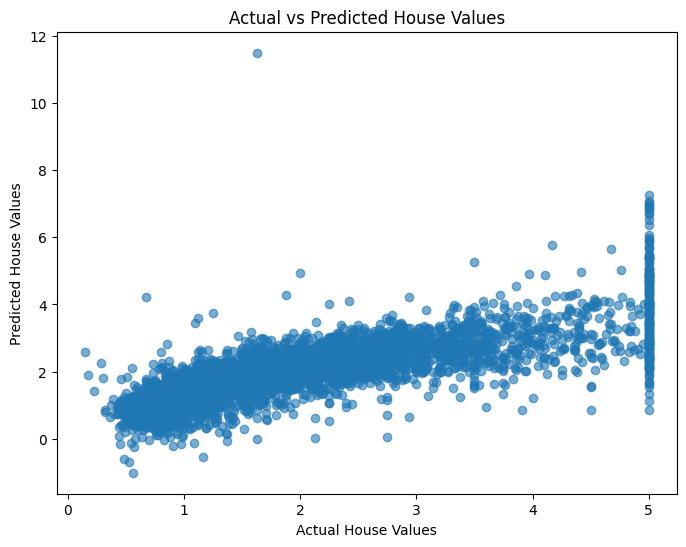

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Actual vs Predicted House Values")

plt.show()

In [11]:
# Create a sample house using the same 8 features as the dataset
sample_house = X.iloc[[0]].copy()

predicted_price = model.predict(sample_house)

print("Sample House Features:")
print(sample_house)

print("\nPredicted House Value:", round(predicted_price[0], 4))

Sample House Features:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127    1.02381       322.0  2.555556     37.88   

   Longitude  
0    -122.23  

Predicted House Value: 4.1519


In [12]:
print("=" * 55)
print("HOUSE PRICE PREDICTION - FINAL RESULT")
print("=" * 55)

print("Model Used        : Linear Regression")
print(f"Training Samples  : {len(X_train)}")
print(f"Testing Samples   : {len(X_test)}")
print(f"MAE               : {mae:.4f}")
print(f"MSE               : {mse:.4f}")
print(f"RMSE              : {rmse:.4f}")
print(f"R² Score          : {r2:.4f}")
print(f"Predicted Value   : {predicted_price[0]:.4f}")

print("\nProject Status: Completed Successfully! ✅")

HOUSE PRICE PREDICTION - FINAL RESULT
Model Used        : Linear Regression
Training Samples  : 16512
Testing Samples   : 4128
MAE               : 0.5332
MSE               : 0.5559
RMSE              : 0.7456
R² Score          : 0.5758
Predicted Value   : 4.1519

Project Status: Completed Successfully! ✅
